# MDN Baseline: Multimodal Conditional Distribution

Investigates whether a **Mixture Density Network (MDN) ensemble** can learn the
synthetic conditional distribution

$$p_\star(y \mid x) = \sum_{k=1}^{K} \pi_k(x)\,\mathcal{N}\!\left(y;\,\mu_k(x),\,\Sigma_k(x)\right)$$

Because the distribution is **fully synthetic**, we have the exact true NLL as an
oracle lower bound.  The **calibration gap**

$$\Delta = \text{ensemble NLL} - \text{true NLL}$$

tells us precisely how well the model has learned — a diagnostic unavailable in the
physical-system examples.

In [49]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # replace with desired GPU
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

%matplotlib inline
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import jax
import jax.numpy as jnp
from jax import random

import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [51]:
%autoreload 2

_repo_root   = str(Path("../..").resolve())
_example_dir = str(Path(".").resolve())
for _p in [_repo_root, _example_dir]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import optax
from jaxmix.archs import MLP, MDN, Ensemble
from jaxmix.trainers import MDNTrainer, MSETrainer
from jaxmix.utils import split_data
from jaxmix.data_loaders import BatchedDataset

from multimodal_conditional import (
    build_distribution,
    generate_dataset,
    compute_true_nll,
    plot_output_marginals,
    plot_output_scatter_by_component,
    plot_log_prob_distribution,
)
from active_learning_utils import create_shared_multimodal_data
from examples.common_active_learning import evaluate_ensemble_nll

In [52]:
key = random.PRNGKey(42)
model_init_key = random.PRNGKey(67)

## Build the Distribution

`build_distribution` draws **all** model parameters once from a fixed PRNGKey and
returns a `generate_samples(x, key)` oracle and a `log_prob(y, x)` oracle.
The same `dist_seed` always produces the identical distribution.

In [53]:
# ----- Distribution hyperparameters (MUST match active_learning.ipynb) -----
D         = 10    # input  dimension  (x ∈ R^D)
M         = 16    # output dimension  (y ∈ R^M)
L         = 4     # latent manifold dimension (L << D)
K         = 3     # true number of mixture components
P         = 128   # random Fourier features
TAU       = 1.0   # softmax temperature
ALPHA     = 0.0   # variance coupling (disabled)
C_SCALE   = 10.0  # mode-separation scale
DIST_SEED = 42    # fixed forever — defines the distribution

# ----- Structured mixing (must match active_learning.ipynb) -----
MIXING_MODE          = "structured"
TRANSITION_SHARPNESS = 8.0
TRANSITION_RADIUS    = 1.3
ANGULAR_SHARPNESS    = 2.0
LOGIT_SCALE          = 3.0

generate_samples, log_prob = build_distribution(
    d=D, m=M, L=L, K=K, p=P,
    tau=TAU, alpha=ALPHA, c_scale=C_SCALE,
    seed=DIST_SEED,
    mixing_mode=MIXING_MODE,
    transition_sharpness=TRANSITION_SHARPNESS,
    transition_radius=TRANSITION_RADIUS,
    angular_sharpness=ANGULAR_SHARPNESS,
    logit_scale=LOGIT_SCALE,
)

print(f"Mixing mode: {MIXING_MODE}")
print("Distribution parameters:")
for name, arr in generate_samples.get_params().items():
    if hasattr(arr, "shape"):
        print(f"  {name:24s}  shape={arr.shape}")
    else:
        print(f"  {name:24s}  = {arr}")

Mixing mode: structured
Distribution parameters:
  A                         shape=(10, 4)
  b_m                       shape=(10,)
  Omega                     shape=(128, 10)
  phi                       shape=(128,)
  W                         shape=(3, 10)
  B                         shape=(3, 16, 128)
  c                         shape=(3, 16)
  C                         shape=(3, 16, 128)
  b_var                     shape=(3, 16)
  mixing_mode               = structured
  V                         shape=(2, 4)
  transition_sharpness      = 8.0
  transition_radius         = 1.3
  angular_sharpness         = 2.0
  logit_scale               = 3.0


## Generate Dataset

In [54]:
# Use create_shared_multimodal_data so train/test split and true_nll match
# active_learning.ipynb exactly (same seed=42, same dist params, same split).
data = create_shared_multimodal_data(
    seed=42,
    candidate_sample_count=50_000,
    test_sample_count=2_000,
    initial_sample_count=100,
    d=D, m=M, L=L, K=K, p=P,
    tau=TAU, alpha=ALPHA, c_scale=C_SCALE,
    dist_seed=DIST_SEED,
    manifold_seed=1,
    mixing_mode=MIXING_MODE,
    transition_sharpness=TRANSITION_SHARPNESS,
    transition_radius=TRANSITION_RADIUS,
    angular_sharpness=ANGULAR_SHARPNESS,
    logit_scale=LOGIT_SCALE,
)

# Full training set = initial labelled + remaining pool (50,000 points)
train_inputs  = jnp.concatenate(
    [data["initial_labeled_inputs"], data["remaining_pool_inputs"]], axis=0
)
train_outputs = jnp.concatenate(
    [data["initial_labeled_targets"], data["remaining_pool_targets"]], axis=0
)
train_weights = jnp.ones((train_inputs.shape[0],))
train_data    = (train_inputs, train_outputs, train_weights)

test_inputs, test_outputs = data["test_data"]
test_weights = jnp.ones((test_inputs.shape[0],))
test_data    = (test_inputs, test_outputs, test_weights)

print(f"Train : {train_inputs.shape}  ->  {train_outputs.shape}")
print(f"Test  : {test_inputs.shape}  ->  {test_outputs.shape}")
print(f"Output mean : {float(train_outputs.mean()):.5f}  (expected ≈ 0)")
print(f"Output std  : {float(train_outputs.std()):.3f}")
print(f"True NLL (test, from shared benchmark) : {data['true_nll']:.4f}")

Train : (50000, 10)  ->  (50000, 16)
Test  : (2000, 10)  ->  (2000, 16)
Output mean : -0.01436  (expected ≈ 0)
Output std  : 6.416
True NLL (test, from shared benchmark) : 22.9805


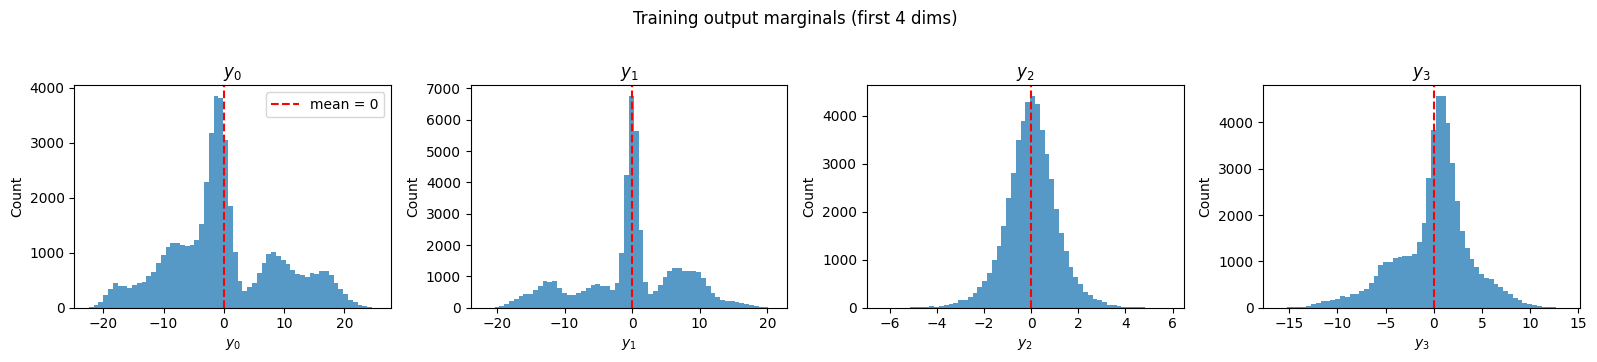

In [55]:
# Output marginals — should show multimodal histograms centred at zero
plot_output_marginals(
    train_outputs, n_dims=4,
    title="Training output marginals (first 4 dims)",
)

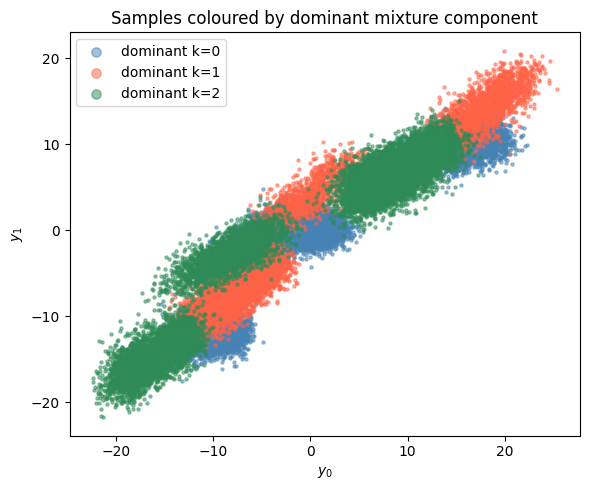

In [56]:
# Scatter coloured by dominant mixture component — reveals K separate clusters
plot_output_scatter_by_component(
    train_inputs, train_outputs, generate_samples,
    K=K, tau=TAU, alpha=ALPHA,
    dim_i=0, dim_j=1,
)

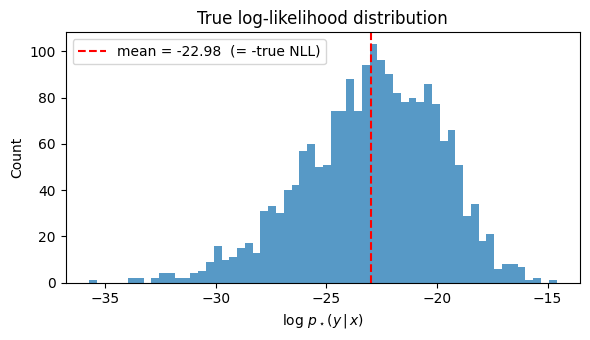

True NLL (test)  : 22.9805
This is the best NLL any perfectly calibrated model can achieve.


In [57]:
# True log-likelihood distribution — mean = −true_NLL (the floor)
plot_log_prob_distribution(log_prob, test_inputs, test_outputs)

true_nll = data["true_nll"]
print(f"True NLL (test)  : {true_nll:.4f}")
print("This is the best NLL any perfectly calibrated model can achieve.")

## Defining Model Architectures

In [58]:
# Architecture matches active_learning.ipynb: hidden=128, depth=2, num_mixtures=5
ensemble_size = 8
num_mixtures  = 5     # > K_true=3; same as AL notebook
hidden = 128
depth = 2

# MSE Baseline
mse_base_arch = MLP(features=[hidden] * depth + [M])
mse_arch = Ensemble(mse_base_arch, ensemble_size)

# MDN 
mdn_base_arch = MLP(features=[hidden] * depth)
mdn_backbone_arch = Ensemble(mdn_base_arch, ensemble_size)
MDN_arch = MDN(
    num_mixtures=num_mixtures,
    num_output_dims=M,
    backbone=mdn_backbone_arch,
    ensemble_size=ensemble_size,
)

# Shared LR schedule + optimiser
num_linear_steps = 2_000
peak_lr          = 5e-4
lr = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=0.0, end_value=peak_lr, transition_steps=num_linear_steps,
        ),
        optax.exponential_decay(
            init_value=peak_lr, transition_steps=2_000, decay_rate=0.9,
        ),
    ],
    boundaries=[num_linear_steps],
)
optimizer = optax.chain(
    optax.adaptive_grad_clip(0.1),
    optax.adamw(learning_rate=lr, weight_decay=1e-5),
)

## MSE Baseline Training

The MSE model minimises $\mathbb{E}[\|y - \hat{y}(x)\|^2]$.  Because
$\mathbb{E}[y|x] = 0$ for all $x$, the optimal predictor is the zero function.
It cannot capture any spread or multimodality in the conditional distribution.

In [59]:
init_batch = (train_inputs, train_outputs, train_weights)
key, subkey = random.split(model_init_key)
mse_model = MSETrainer(
    mse_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mse_model.tabulate())


                                         Ensemble Summary                                          
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module   ┃ inputs             ┃ outputs             ┃ params                     ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│              │ Ensemble │ float32[50000,10]  │ float32[8,50000,16] │                            │
├──────────────┼──────────┼────────────────────┼─────────────────────┼────────────────────────────┤
│ arch         │ MLP      │ float32[50000,10]  │ float32[50000,16]   │                            │
├──────────────┼──────────┼────────────────────┼─────────────────────┼────────────────────────────┤
│ arch/Dense_0 │ Dense    │ float32[50000,10]  │ float32[50000,128]  │ bias: float32[8,128]       │
│              │          │                    │                     │ kernel: float32[8,10,128]  │

In [60]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=128)
mse_model.train(train_loader, nIter=60_000)

100%|██████████| 60000/60000 [00:46<00:00, 1287.26it/s, loss=1.0649436, grad_norm=0.06476982]  


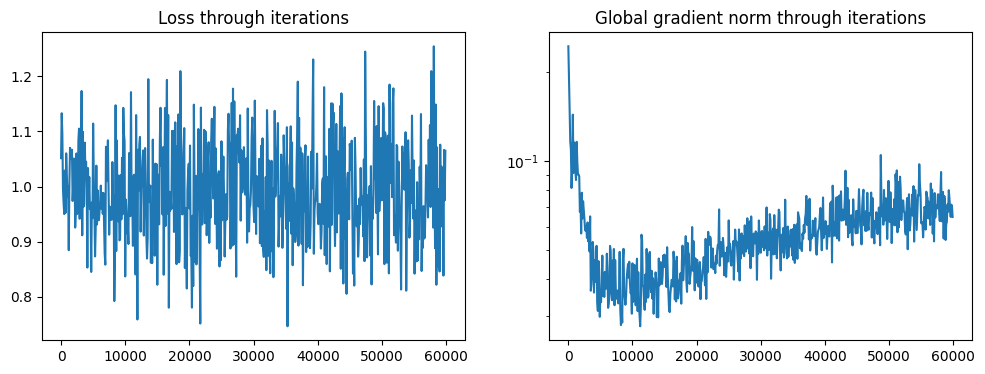

In [61]:
mse_model.plot_logs()

## MDN Training

The MDN maximises the log-likelihood of $p_\star(y|x)$ under its mixture model.
Negative NLL should converge towards the true NLL computed above.

In [62]:
key, subkey = random.split(model_init_key)
mdn_model = MDNTrainer(
    MDN_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mdn_model.tabulate())


                                                      MDN Summary                                                       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module       ┃ inputs                 ┃ outputs                 ┃ params                     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ MDN          │ float32[50000,10]      │ - float32[8,50000,5,1]  │                            │
│                       │              │                        │ - float32[8,50000,5,16] │                            │
│                       │              │                        │ - float32[8,50000,5,16] │                            │
├───────────────────────┼──────────────┼────────────────────────┼─────────────────────────┼────────────────────────────┤
│ backbone              │ Ensem

In [63]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=128)
mdn_model.train(train_loader, nIter=80_000)

100%|██████████| 80000/80000 [01:09<00:00, 1154.28it/s, loss=-0.45563823, grad_norm=10.979194]   


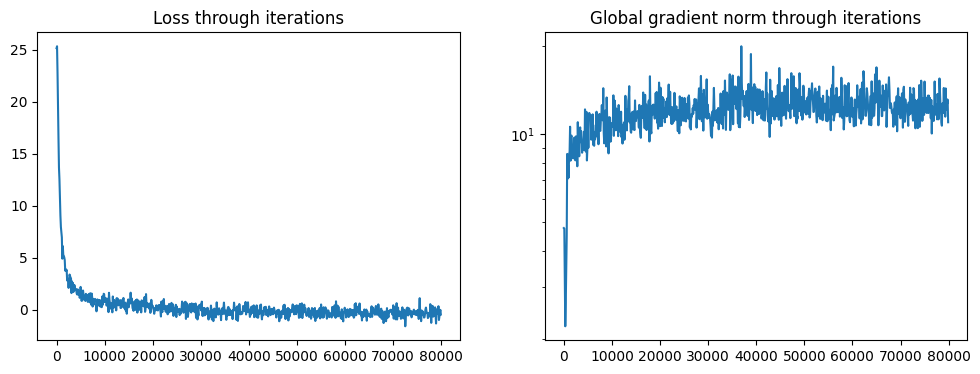

In [64]:
mdn_model.plot_logs()

In [65]:
# MDN ensemble NLL on test set
mdn_nll = evaluate_ensemble_nll(mdn_model, test_inputs, test_outputs)
gap     = mdn_nll - true_nll

# MSE test loss (mean per output dim)
mse_preds = mse_model.apply(mse_model.params, test_inputs)  # (E, N, M)
mse_mean_pred = float(mse_preds.mean(axis=0).mean())         # grand mean ≈ 0
mse_test_loss = float(((mse_preds.mean(axis=0) - test_outputs) ** 2).mean())

print(f"True NLL (oracle floor) : {true_nll:.4f}")
print(f"MDN ensemble NLL        : {mdn_nll:.4f}")
print(f"Calibration gap  Δ      : {gap:.4f}  (MDN NLL − true NLL)")
print()
print(f"MSE model mean output   : {mse_mean_pred:.5f}  (expected ≈ 0)")
print(f"MSE test loss           : {mse_test_loss:.4f}  (≈ output variance)")

True NLL (oracle floor) : 22.9805
MDN ensemble NLL        : 24.7141
Calibration gap  Δ      : 1.7337  (MDN NLL − true NLL)

MSE model mean output   : -0.00579  (expected ≈ 0)
MSE test loss           : 41.2334  (≈ output variance)


## Single-Gaussian (K=1) MDN Baseline

Intermediate between MSE and the full MDN: an `MDNTrainer` with `num_mixtures=1`
is a Gaussian-NLL model.  It captures the conditional **mean and variance** but
is structurally incapable of representing multimodality — a useful diagnostic for
how much of the MDN's advantage comes from modelling spread vs. modelling modes.

In [66]:
MDN_single_arch = MDN(
    num_mixtures=1,
    num_output_dims=M,
    backbone=mdn_backbone_arch,
    ensemble_size=ensemble_size,
)

key, subkey = random.split(model_init_key)
mdn_single_model = MDNTrainer(
    MDN_single_arch, init_batch, key=subkey, optimizer=optimizer,
    normalize_inputs=True, normalize_outputs=True,
)
print(mdn_single_model.tabulate())


                                                      MDN Summary                                                       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module       ┃ inputs                 ┃ outputs                 ┃ params                     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ MDN          │ float32[50000,10]      │ - float32[8,50000,1,1]  │                            │
│                       │              │                        │ - float32[8,50000,1,16] │                            │
│                       │              │                        │ - float32[8,50000,1,16] │                            │
├───────────────────────┼──────────────┼────────────────────────┼─────────────────────────┼────────────────────────────┤
│ backbone              │ Ensem

100%|██████████| 80000/80000 [01:04<00:00, 1235.03it/s, loss=20.915424, grad_norm=1.4042877] 


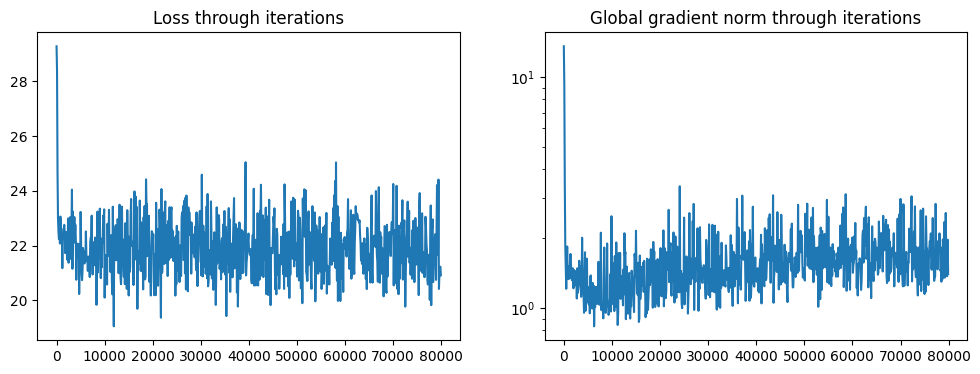

In [67]:
key, loader_key = random.split(key)
train_loader = BatchedDataset(train_data, loader_key, batch_size=128)
mdn_single_model.train(train_loader, nIter=80000)
mdn_single_model.plot_logs()

In [68]:
mdn_single_nll = evaluate_ensemble_nll(mdn_single_model, test_inputs, test_outputs)

print(f"True NLL (oracle floor)     : {true_nll:.4f}")
print(f"MDN (K={num_mixtures}) ensemble NLL   : {mdn_nll:.4f}")
print(f"MDN (K=1) ensemble NLL        : {mdn_single_nll:.4f}")
gap_single = mdn_single_nll - true_nll
print(f"Calibration gap Δ (single-G) : {gap_single:.4f}")

True NLL (oracle floor)     : 22.9805
MDN (K=5) ensemble NLL   : 24.7141
MDN (K=1) ensemble NLL        : 47.7639
Calibration gap Δ (single-G) : 24.7834


## Visual Comparison

### 1. NLL summary bar chart

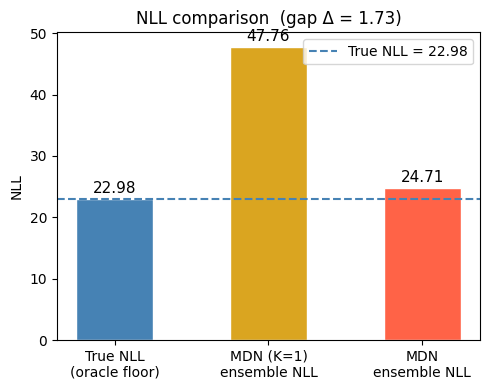

In [69]:
labels = ["True NLL\n(oracle floor)", "MDN (K=1)\nensemble NLL", "MDN\nensemble NLL"]
values = [true_nll, mdn_single_nll, mdn_nll]
colors = ["steelblue", "goldenrod", "tomato"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.5)
ax.axhline(true_nll, color="steelblue", linestyle="--", linewidth=1.5,
           label=f"True NLL = {true_nll:.2f}")
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.2f}", ha="center", va="bottom", fontsize=11,
    )
ax.set_ylabel("NLL")
ax.set_title(f"NLL comparison  (gap Δ = {gap:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

### 2. Predicted samples vs. true samples  (y₀ − y₁ scatter)

The MDN samples one $y$ per test input from the mixture.  Three distinct clusters
in the scatter indicate successful recovery of the $K=3$ components.

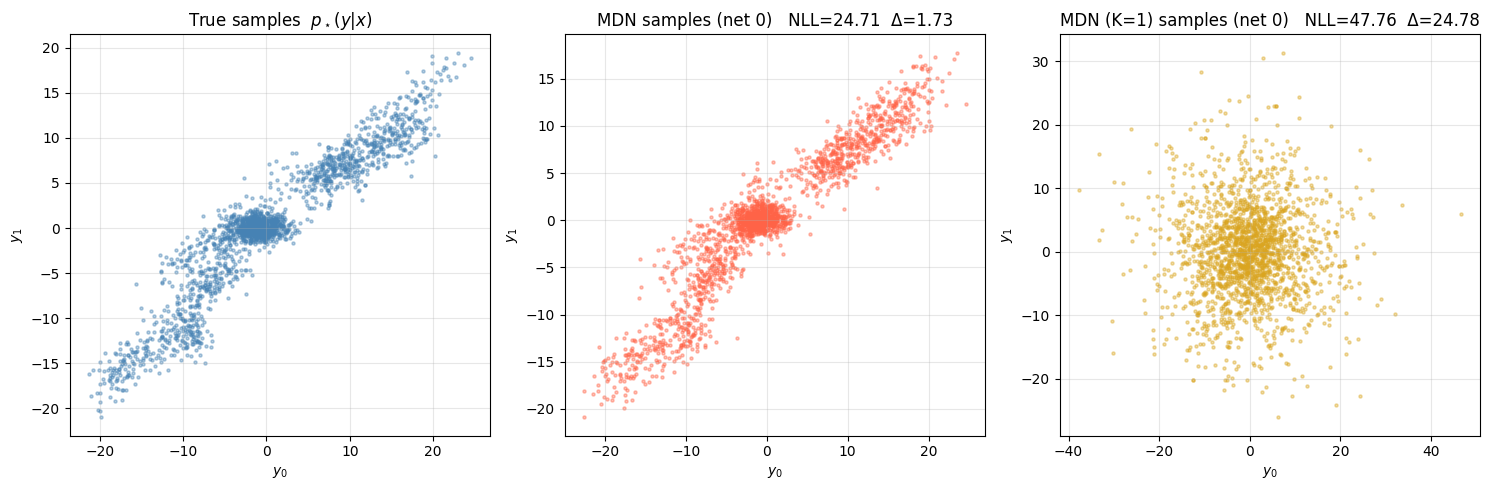

In [70]:
import os

# Sample from MDN (net 0)
pred = mdn_model.apply(mdn_model.params, test_inputs)
logit_weights, means, variances = pred
mdn_samples = mdn_model.sample_from_mixture(
    random.PRNGKey(0), logit_weights, means, variances,
)  # (E, N, 1, M)
y_net0 = np.asarray(mdn_samples[0]).squeeze(1)   # (N, M)

# Sample from single-Gaussian MDN (K=1), net 0
pred_single = mdn_single_model.apply(mdn_single_model.params, test_inputs)
lw_s, mu_s, var_s = pred_single
mdn_single_samples = mdn_single_model.sample_from_mixture(
    random.PRNGKey(1), lw_s, mu_s, var_s,
)
y_single_net0 = np.asarray(mdn_single_samples[0]).squeeze(1)

n_show = min(4000, test_inputs.shape[0])
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# True samples
ax = axes[0]
ax.scatter(np.asarray(test_outputs[:n_show, 0]),
           np.asarray(test_outputs[:n_show, 1]),
           s=5, alpha=0.4, c="steelblue")
ax.set_xlabel("$y_0$"); ax.set_ylabel("$y_1$")
ax.set_title("True samples  $p_\\star(y|x)$")
ax.grid(True, alpha=0.3)

# MDN samples (net 0)
ax = axes[1]
ax.scatter(y_net0[:n_show, 0], y_net0[:n_show, 1],
           s=5, alpha=0.4, c="tomato")
ax.set_xlabel("$y_0$"); ax.set_ylabel("$y_1$")
ax.set_title(f"MDN samples (net 0)   NLL={mdn_nll:.2f}  Δ={gap:.2f}")
ax.grid(True, alpha=0.3)

# MDN (K=1) samples (net 0)
ax = axes[2]
ax.scatter(y_single_net0[:n_show, 0], y_single_net0[:n_show, 1],
           s=5, alpha=0.4, c="goldenrod")
ax.set_xlabel("$y_0$"); ax.set_ylabel("$y_1$")
ax.set_title(f"MDN (K=1) samples (net 0)   NLL={mdn_single_nll:.2f}  Δ={gap_single:.2f}")
ax.grid(True, alpha=0.3)

# plt.suptitle("Predicted vs true output samples  ($y_0$, $y_1$)", fontsize=14)
plt.tight_layout()
plt.show()

### 3. Output marginals: true vs MDN samples

Overlaid histograms for the first four output dimensions.

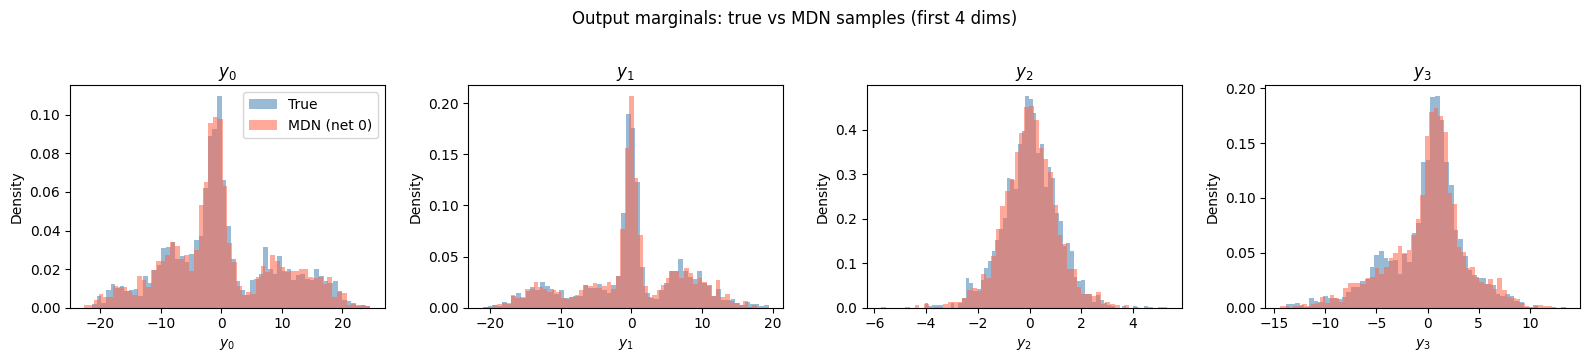

In [71]:
if "y_net0" not in globals():
    logit_weights, means, variances = mdn_model.apply(mdn_model.params, test_inputs)
    mdn_samples = mdn_model.sample_from_mixture(
        random.PRNGKey(0), logit_weights, means, variances,
    )
    y_net0 = np.asarray(mdn_samples[0]).squeeze(1)

n_dims = 4
fig, axes = plt.subplots(1, n_dims, figsize=(4 * n_dims, 3.5))

for i, ax in enumerate(axes):
    ax.hist(np.asarray(test_outputs[:, i]), bins=60,
            alpha=0.55, color="steelblue", label="True", density=True)
    ax.hist(y_net0[:, i], bins=60,
            alpha=0.55, color="tomato", label="MDN (net 0)", density=True)
    ax.set_title(f"$y_{{{i}}}$")
    ax.set_xlabel(f"$y_{{{i}}}$")
    ax.set_ylabel("Density")
    if i == 0:
        ax.legend()

plt.suptitle("Output marginals: true vs MDN samples (first 4 dims)", y=1.02)
plt.tight_layout()
plt.show()

### 4. Ensemble spread  (all nets on same test point)

Each ensemble member independently samples from its own mixture.  The spread
across nets reflects epistemic uncertainty — high spread signals regions where
the model is less confident about the conditional distribution.

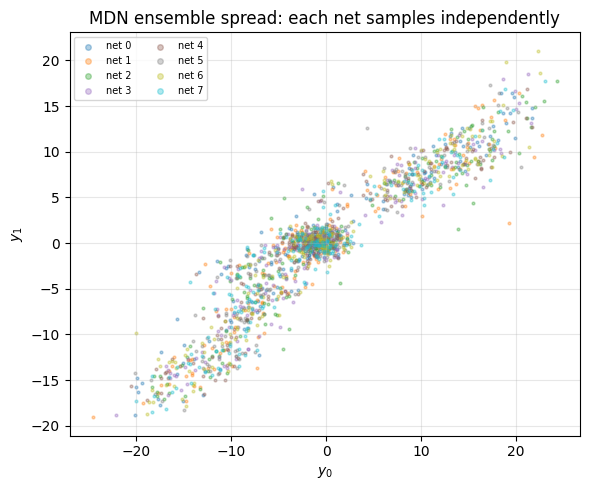

Per-net MDN NLL:
  Net 0: 25.6060
  Net 1: 26.1411
  Net 2: 25.9921
  Net 3: 25.4970
  Net 4: 25.8205
  Net 5: 25.2622
  Net 6: 25.3405
  Net 7: 25.7644
  MDN ensemble (avg over nets): 24.7141
  True NLL (floor)            : 22.9805


In [72]:
if "mdn_samples" not in globals():
    logit_weights, means, variances = mdn_model.apply(mdn_model.params, test_inputs)
    mdn_samples = mdn_model.sample_from_mixture(
        random.PRNGKey(0), logit_weights, means, variances,
    )

# One sample per network for the same test inputs
all_net_samples = np.asarray(mdn_samples).squeeze(2)   # (E, N, M)

colors_nets = plt.cm.tab10(np.linspace(0, 1, ensemble_size))
n_show_ens = min(200, test_inputs.shape[0])

fig, ax = plt.subplots(figsize=(6, 5))
for e_idx in range(ensemble_size):
    ax.scatter(
        all_net_samples[e_idx, :n_show_ens, 0],
        all_net_samples[e_idx, :n_show_ens, 1],
        s=4, alpha=0.35, color=colors_nets[e_idx],
        label=f"net {e_idx}",
    )
ax.set_xlabel("$y_0$"); ax.set_ylabel("$y_1$")
ax.set_title("MDN ensemble spread: each net samples independently")
ax.legend(markerscale=2, fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Per-net NLL
print("Per-net MDN NLL:")
from jaxmix.trainers import mdn_loss_func
lw, mu, var = logit_weights, means, variances
per_net_nll = mdn_loss_func(lw, mu, var, test_outputs)  # (E, N, 1)
for e_idx in range(ensemble_size):
    nll_e = float(per_net_nll[e_idx].mean())
    print(f"  Net {e_idx}: {nll_e:.4f}")
print(f"  MDN ensemble (avg over nets): {mdn_nll:.4f}")
print(f"  True NLL (floor)            : {true_nll:.4f}")